## Phenotype file preparation

In [1]:
# Import required libraries
import os
import pandas as pd
import numpy as np
from datetime import datetime
import plotnine
from plotnine import *
import pandas_gbq
import matplotlib.pyplot as plt

## Get environment variables for paths instead of running Setting_Env_Variables
#bucket = os.getenv("WORKSPACE_BUCKET")   # Workspace bucket path
#dataset = os.getenv("WORKSPACE_CDR")     # Dataset path
#dataset = %env WORKSPACE_CDR

In [2]:
#not necessary but helps you visualise the workspace
!wb workspace set --id=pelvic-inflammatory-disease

Workspace successfully loaded.
ID:                   pelvic-inflammatory-disease
Name:                 Pelvic Inflammatory disease
Description:          The Workspace will be used to perform genome-wide association analyses (GWAS) in the All of Us cohort for Pelvic Inflammatory Disease. The analysis will primarily use women of European descent. However, depending on sample size, GWAS may also be run using other ancestries.
Cloud Platform:       GCP
Highest Role:         OWNER
Organization:         aou-prod
Pod:                  user-pod-nathani-d86e
Google project:       wb-blinding-cabbage-2295
Cloud console:        https://console.cloud.google.com/home/dashboard?project=wb-blinding-cabbage-2295
Properties:
  terra-default-location: us-central1
  terra-workspace-short-description: investigate the genetic drivers of pelvic inflammatory disease in women
  terra-required-data-use-metadata: [{"form_id":"AOU-CDR-V8","form_data":{"purposeOtherText":"","purposeDiseaseText":"Pelvic Inflammato

In [3]:
#run once per workspace
#%run /home/jupyter/workspace/workspace-scripts/Var_set.ipynb

In [4]:
#run in every new notebook
%run /home/jupyter/workspace/workspace-scripts/Var_set_2.ipynb

bucket_input:   gs://workspace-bucket-wb-blinding-cabbage-2295
bucket_output:  gs://workspace-output-wb-blinding-cabbage-2295
bucket_scripts: gs://script-wb-blinding-cabbage-2295
bucket_GenDat: gs://workspace-gendat-wb-blinding-cabbage-2295
dataset:        wb-silky-artichoke-2408.C2024Q3R8


## Extract Phenotype Using SQL  
Here, I will demonstrate an approach using a custom **SQL query**, within the pandas_gbq Python library

### Check Concept Codes  

A patient’s electronic health record (EHR) may contain the same medical information recorded in different ways, depending on the healthcare provider or system.  

For example:  
- **ICD-9**:   
- **ICD-10**  

When the *All of Us* program receives a participant’s EHR, these source codes are mapped to a **standard vocabulary** to ensure consistency -> **SNOMED**.  

By mapping all source codes to standard codes, data from multiple healthcare systems can be integrated, categorized, and searched more effectively. This process reduces discrepancies between coding schemes and improves data quality for research.  


In [5]:
# To check vocabulary_id AoU used
query = f""" 
SELECT DISTINCT vocabulary_id
FROM `{dataset}.concept`
ORDER BY vocabulary_id;
"""

vocabulary_id_df = pandas_gbq.read_gbq(query, dialect="standard")
vocabulary_id_df['vocabulary_id'].tolist()

Downloading: 100%|██████████|


['ABMS',
 'APC',
 'ATC',
 'AoU_Custom',
 'AoU_General',
 'CDM',
 'CIEL',
 'CMS Place of Service',
 'CPT4',
 'CVX',
 'Cancer Modifier',
 'Concept Class',
 'Condition Status',
 'Condition Type',
 'Cost',
 'Cost Type',
 'Currency',
 'DRG',
 'Death Type',
 'Device Type',
 'Domain',
 'Drug Type',
 'Episode',
 'Episode Type',
 'Ethnicity',
 'Gender',
 'HCPCS',
 'HemOnc',
 'ICD10CM',
 'ICD10PCS',
 'ICD9CM',
 'ICD9Proc',
 'ICDO3',
 'Korean Revenue Code',
 'LOINC',
 'Language',
 'MDC',
 'Meas Type',
 'Medicare Specialty',
 'Metadata',
 'Multum',
 'NAACCR',
 'NDC',
 'NDFRT',
 'NUCC',
 'Nebraska Lexicon',
 'None',
 'Note Type',
 'OMOP Extension',
 'OMOP Genomic',
 'OSM',
 'Obs Period Type',
 'Observation Type',
 'PCORNet',
 'PPI',
 'Plan',
 'Plan Stop Reason',
 'Procedure Type',
 'Provider',
 'Race',
 'Relationship',
 'Revenue Code',
 'RxNorm',
 'RxNorm Extension',
 'SNOMED',
 'SOPT',
 'SPL',
 'Specimen Type',
 'Sponsor',
 'Supplier',
 'Type Concept',
 'UB04 Point of Origin',
 'UB04 Pri Typ of Ad

In [6]:
# Check concept code (ICD9CM)
query = f"""
SELECT DISTINCT concept_id, concept_code, concept_name
FROM `{dataset}.concept`
WHERE vocabulary_id = 'ICD9CM'
ORDER BY concept_code
"""

icd9cm_options_df = pandas_gbq.read_gbq(query, dialect="standard")
icd9cm_options_df

Downloading: 100%|██████████|


,concept_id,concept_code,concept_name
0,44829696,001,Cholera
1,44835564,001.0,Cholera due to vibrio cholerae
2,44823922,001.1,Cholera due to vibrio cholerae el tor
3,44827441,001.9,"Cholera, unspecified"
4,44829697,002,Typhoid and paratyphoid fevers
...,...,...,...
17559,44837889,V91.90,"Other specified multiple gestation, unspecifie..."
17560,44820514,V91.91,"Other specified multiple gestation, with two o..."
17561,44837890,V91.92,"Other specified multiple gestation, with two o..."
17562,44820515,V91.99,"Other specified multiple gestation, unable to ..."


In [7]:
# Check concept code (ICD10CM)
query = f"""                                
SELECT DISTINCT concept_id, concept_code, concept_name
FROM `{dataset}.concept`
WHERE vocabulary_id = 'ICD10CM'
ORDER BY concept_code
"""

icd10cm_options_df = pandas_gbq.read_gbq(query, dialect="standard")
icd10cm_options_df

Downloading: 100%|██████████|


,concept_id,concept_code,concept_name
0,1567237,A00,Cholera
1,35205396,A00.0,"Cholera due to Vibrio cholerae 01, biovar chol..."
2,35205397,A00.1,"Cholera due to Vibrio cholerae 01, biovar eltor"
3,35205398,A00.9,"Cholera, unspecified"
4,1567238,A01,Typhoid and paratyphoid fevers
...,...,...,...
98578,35225437,Z99.3,Dependence on wheelchair
98579,1576313,Z99.8,Dependence on other enabling machines and devices
98580,45600392,Z99.81,Dependence on supplemental oxygen
98581,45595570,Z99.89,Dependence on other enabling machines and devices


In [8]:
# Check concept code (SNOMED)
query = f"""                                
SELECT DISTINCT concept_id, concept_code, concept_name
FROM `{dataset}.concept`
WHERE vocabulary_id = 'SNOMED'
ORDER BY concept_code
"""

snomed_options_df = pandas_gbq.read_gbq(query, dialect="standard")
snomed_options_df

Downloading: 100%|██████████|


,concept_id,concept_code,concept_name
0,4000935,100000000,BITTER-3
1,3627602,10000001000001107,SIGVARIS 200 medium/plus/17348 class 2(23-32mm...
2,4001098,10000006,Radiating chest pain
3,37392117,1000001000000103,Urine tryptophan:creatinine ratio
4,3587688,1000001000001104,Gelcosal 5% gel 50g
...,...,...,...
1054930,46139743,9999811000001102,Nu-Hope belt right large 6457 90cm-100cm lengt...
1054931,4322221,99999003,BISMUSAL SUSPENSION
1054932,3627601,9999901000001105,SIGVARIS 200 small/plus/17347 class 2(23-32mmH...
1054933,37398454,999991000000109,Urine tyrosine:creatinine ratio


In [9]:
# Change your phenotype code here (snomed)
# Check All of Us Data Brower: https://databrowser.researchallofus.org/

# Code for PID 
pheno_icd9 = "614"
pheno_icd10 = ("N70","N71","N73","N74")
pheno_snomed = "198130006"


In [10]:
icd9cm_options_df[icd9cm_options_df["concept_code"].str.startswith(pheno_icd9)]

,concept_id,concept_code,concept_name
7495,44836050,614,"Inflammatory disease of ovary, fallopian tube,..."
7496,44825562,614.0,Acute salpingitis and oophoritis
7497,44832500,614.1,Chronic salpingitis and oophoritis
7498,44831343,614.2,Salpingitis and oophoritis not specified as ac...
7499,44833678,614.3,Acute parametritis and pelvic cellulitis
7500,44825563,614.4,Chronic or unspecified parametritis and pelvic...
7501,44824360,614.5,"Acute or unspecified pelvic peritonitis, female"
7502,44823202,614.6,"Pelvic peritoneal adhesions, female (postopera..."
7503,44822050,614.7,"Other chronic pelvic peritonitis, female"
7504,44820986,614.8,Other specified inflammatory disease of female...


In [11]:
icd10cm_options_df[icd10cm_options_df["concept_code"].str.startswith(pheno_icd10)]

,concept_id,concept_code,concept_name
25014,1571555,N70,Salpingitis and oophoritis
25015,1571556,N70.0,Acute salpingitis and oophoritis
25016,45577539,N70.01,Acute salpingitis
25017,45558166,N70.02,Acute oophoritis
25018,45582418,N70.03,Acute salpingitis and oophoritis
25019,1571557,N70.1,Chronic salpingitis and oophoritis
25020,45582419,N70.11,Chronic salpingitis
25021,45548678,N70.12,Chronic oophoritis
25022,45543887,N70.13,Chronic salpingitis and oophoritis
25023,1571558,N70.9,"Salpingitis and oophoritis, unspecified"


In [12]:
snomed_options_df[snomed_options_df["concept_code"].str.startswith(pheno_snomed)]

,concept_id,concept_code,concept_name
283927,199067,198130006,Female pelvic inflammatory disease


In [13]:
condition_codes_icd9 = tuple(icd9cm_options_df[icd9cm_options_df["concept_code"].str.startswith(pheno_icd9)]["concept_code"])
condition_codes_icd10 = tuple(icd10cm_options_df[icd10cm_options_df["concept_code"].str.startswith(pheno_icd10)]["concept_code"])
condition_codes_snomed = tuple(snomed_options_df[snomed_options_df["concept_code"].str.startswith(pheno_snomed)]["concept_code"])
# print(condition_codes_icd10)
# print(len(condition_codes_icd10))

In [14]:
# Convert lists into SQL IN (...) strings
icd9_str = "(" + ",".join(f"'{c}'" for c in condition_codes_icd9) + ")"
icd10_str = "(" + ",".join(f"'{c}'" for c in condition_codes_icd10) + ")"
snomed_str = "(" + ",".join(f"'{c}'" for c in pheno_snomed) + ")"


In [15]:
icd9_str

"('614','614.0','614.1','614.2','614.3','614.4','614.5','614.6','614.7','614.8','614.9')"

In [16]:
# Gather all the concept ids related to phenotype

# Build SQL query
query = f"""                                
SELECT 
    c.concept_name, c.concept_code, c.concept_id
FROM `{dataset}.concept` c
JOIN `{dataset}.condition_occurrence` co 
    ON c.concept_id = co.condition_source_concept_id
WHERE (vocabulary_id='ICD9CM' AND concept_code IN {icd9_str})
   OR (vocabulary_id='ICD10CM' AND concept_code IN {icd10_str})
   OR (vocabulary_id='SNOMED' AND concept_code IN {snomed_str})
GROUP BY c.concept_name, c.concept_code, c.concept_id
"""

# Run query
condition_concepts_df = pandas_gbq.read_gbq(query, dialect="standard")
condition_concepts_df

Downloading: 100%|██████████|


,concept_name,concept_code,concept_id
0,Female pelvic peritoneal adhesions (postinfect...,N73.6,35209375
1,Chronic oophoritis,N70.12,45548678
2,Other specified female pelvic inflammatory dis...,N73.8,35209376
3,Acute salpingitis and oophoritis,N70.03,45582418
4,Chronic salpingitis and oophoritis,N70.1,1571557
5,Acute oophoritis,N70.02,45558166
6,"Oophoritis, unspecified",N70.92,45567858
7,"Inflammatory disease of ovary, fallopian tube,...",614,44836050
8,Unspecified inflammatory disease of female pel...,614.9,44834850
9,"Other chronic pelvic peritonitis, female",614.7,44822050


In [17]:
# Create phenotype cohort

# Select all participants (person_id) who have at least one record in 
# condition_occurrence where the condition_source_concept_id matches 
# any of the concept IDs in our phenotype list we just created

# Add an indicator variable (T2D = 1) to mark these participants as cases
query = f"""                                
SELECT person.person_id,
       1 AS PID
FROM `{dataset}.person` person
WHERE person_id IN (
    SELECT person_id
    FROM `{dataset}.condition_occurrence`
    WHERE condition_source_concept_id IN {tuple(condition_concepts_df['concept_id'].astype(int).tolist())}
)
"""
case_cohort = pandas_gbq.read_gbq(query, dialect="standard")
case_cohort

Downloading: 100%|██████████|


,person_id,PID
0,8018819,1
1,3246929,1
2,1102098,1
3,3270541,1
4,1218204,1
...,...,...
7110,4949198,1
7111,1119881,1
7112,2829962,1
7113,3904814,1


In [18]:
# Check duplicate person_id
int(case_cohort.iloc[:, 0].duplicated().sum())

0

In [19]:
# Get demographic information for participants with whole genome sequencing (WGS) data
# Retrieve person_id, date of birth, and sex at birth (mapped from concept table)
person_sql = f"""
SELECT  
    person.person_id,
    person.birth_datetime,
    p_sex_at_birth_concept.concept_name AS sex_at_birth
FROM `{dataset}.person` person
LEFT JOIN `{dataset}.concept` p_sex_at_birth_concept 
    ON person.sex_at_birth_concept_id = p_sex_at_birth_concept.concept_id
WHERE person.person_id IN (
    SELECT person_id
    FROM `{dataset}.cb_search_person` cb_search_person
    WHERE cb_search_person.person_id IN (
        SELECT person_id
        FROM `{dataset}.cb_search_person` p
        WHERE has_whole_genome_variant = 1
    )
)
"""
wgs_demog = pandas_gbq.read_gbq(person_sql, dialect="standard")
wgs_demog.head(5)

Downloading: 100%|██████████|


,person_id,birth_datetime,sex_at_birth
0,1447308,1969-06-15 00:00:00+00:00,Sex At Birth: Sex At Birth None Of These
1,1459381,1956-06-15 00:00:00+00:00,Sex At Birth: Sex At Birth None Of These
2,2059577,1998-06-15 00:00:00+00:00,Sex At Birth: Sex At Birth None Of These
3,2803379,1983-06-15 00:00:00+00:00,Sex At Birth: Sex At Birth None Of These
4,3496558,1979-06-15 00:00:00+00:00,Sex At Birth: Sex At Birth None Of These


In [20]:
# Merge WGS demographic data with the phenotype cohort
# - Use a left join to keep all WGS participants
# - Fill missing phenotype indicator values with 0 (participants without the condition)
wgs_cohort = (
    wgs_demog.merge(case_cohort, on='person_id', how='left')
              .fillna(value={'PID': 0})
)

# Check the distribution of case/control
wgs_cohort['PID'].value_counts()

PID
0    408992
1      5838
Name: count, dtype: Int64

In [21]:
wgs_cohort.head()

,person_id,birth_datetime,sex_at_birth,PID
0,1447308,1969-06-15 00:00:00+00:00,Sex At Birth: Sex At Birth None Of These,0
1,1459381,1956-06-15 00:00:00+00:00,Sex At Birth: Sex At Birth None Of These,0
2,2059577,1998-06-15 00:00:00+00:00,Sex At Birth: Sex At Birth None Of These,0
3,2803379,1983-06-15 00:00:00+00:00,Sex At Birth: Sex At Birth None Of These,0
4,3496558,1979-06-15 00:00:00+00:00,Sex At Birth: Sex At Birth None Of These,0


# Covariate file preparation

## Ancestry and PCs file

In [22]:
ancestry_pred_path = "gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/ancestry/echo_v4_r2.ancestry_preds.tsv"

In [23]:
# Ancestry and PCs
ancestry_pred = pd.read_csv(ancestry_pred_path, delimiter="\t",storage_options={"requester_pays": True})
ancestry_pred.head()

,research_id,ancestry_pred,probabilities,pca_features,ancestry_pred_other
0,1000000,afr,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[-0.29356093859992993, -0.006344531427051658, ...",afr
1,1000004,eur,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0]","[0.10130837407349723, 0.13870298220174238, 0.0...",eur
2,1000033,eur,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0]","[0.09848604976046149, 0.1245991833533566, 0.00...",eur
3,1000039,afr,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[-0.26713841551900935, 0.00469795004195689, 0....",afr
4,1000042,afr,"[0.99, 0.01, 0.0, 0.0, 0.0, 0.0]","[-0.2562773941608334, 0.004901392894403225, -0...",afr


In [24]:
# Remove brackets and split PCA features
PCs = ancestry_pred["pca_features"].str[1:-1].str.split(",", expand=True).astype(float)

# Assign column names
PCs.columns = [f"PC{i}" for i in range(1, 17)]

# Select columns and concatenate
PCs_final = pd.concat([ancestry_pred[["research_id", "ancestry_pred", "ancestry_pred_other"]], PCs], axis=1)

# Rename final columns
PCs_final.columns = ["IID", "ancestry_pred", "ancestry_pred_other"] + list(PCs.columns)
PCs_final

,IID,ancestry_pred,ancestry_pred_other,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
0,1000000,afr,afr,-0.293561,-0.006345,0.002386,0.001446,0.024304,-0.001529,-0.005621,-0.001204,-0.000920,0.006886,0.004709,0.004915,0.011461,0.002675,-0.001492,0.000896
1,1000004,eur,eur,0.101308,0.138703,0.006683,0.053012,0.003345,0.019714,-0.011616,-0.001016,-0.001095,-0.000909,-0.001277,-0.000694,-0.000668,-0.000960,-0.001257,0.000115
2,1000033,eur,eur,0.098486,0.124599,0.009398,0.042617,0.003846,0.026659,-0.018481,-0.001463,-0.001203,0.000465,0.000469,0.000629,0.000019,-0.000210,-0.000013,0.000411
3,1000039,afr,afr,-0.267138,0.004698,0.001046,0.001767,0.031375,0.001713,-0.009450,0.016385,-0.000844,0.001511,0.003544,-0.000247,-0.010346,0.005279,-0.013716,0.008376
4,1000042,afr,afr,-0.256277,0.004901,-0.002448,0.009514,0.008931,0.010683,0.003820,-0.002210,0.010388,-0.008314,-0.002740,0.003094,0.007370,0.001563,-0.002620,0.006765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414825,9999678,eur,eur,0.098743,0.131769,0.010411,0.048562,0.002988,0.021923,-0.017846,-0.002502,-0.000634,0.000194,0.000252,-0.001290,0.001715,-0.000752,-0.000415,-0.000020
414826,9999697,amr,amr,0.085067,0.028602,-0.107409,0.005666,0.000069,-0.012026,0.010985,0.002458,0.001513,-0.001535,-0.001271,-0.001320,-0.000950,-0.001408,-0.003327,0.000309
414827,9999715,eur,eur,0.099530,0.132836,0.008332,0.050046,0.003166,0.023643,-0.015716,-0.002708,-0.001984,-0.001566,0.000294,0.000889,-0.001221,0.001146,-0.000401,0.000165
414828,9999755,eur,oth,0.064499,0.116637,0.009492,0.042075,-0.005982,-0.022958,0.020151,0.001276,0.000953,-0.000316,-0.003218,0.000905,-0.000271,0.000847,0.001971,-0.000443


## Genetic Sex file

In [25]:
Sex_path = "gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/qc/genomics_metrics_Dec142023_1859_02_tz0000.tsv"

In [26]:
Sex = pd.read_csv(Sex_path, delimiter="\t",storage_options={"requester_pays": True})
Sex.head()

,research_id,sample_source,site_id,sex_at_birth,dragen_sex_ploidy,mean_coverage,genome_coverage,aou_hdr_coverage,dragen_contamination,aligned_q30_bases,verify_bam_id2_contamination,biosample_collection_date
0,1000000,WHOLE BLOOD,bcm,Male,XY,36.75,0.9637,0.9910,0.0,123962256262,0.000003,2019-08-29 22:40:00
1,1000004,WHOLE BLOOD,bcm,Male,XY,43.29,0.9696,0.9966,0.0,149328040246,0.000010,2019-07-26 20:28:00
2,1000033,WHOLE BLOOD,bcm,Male,XY,36.18,0.9649,0.9935,0.0,122602264509,0.000011,2019-08-06 15:11:00
3,1000039,WHOLE BLOOD,bcm,Female,XX,34.88,0.9558,0.9942,0.0,115549998525,0.000021,2020-02-11 17:27:00
4,1000042,WHOLE BLOOD,bcm,Male,XY,40.24,0.9673,0.9932,0.0,132828691811,0.000006,2019-06-19 20:54:00


In [27]:
Sex.iloc[:, 4].value_counts(dropna=False)

dragen_sex_ploidy
XX     252081
XY     161259
X0       1031
XXX       173
XYY       138
XO         83
XXY        51
NaN        14
Name: count, dtype: int64

In [28]:
# Mapping XX -> 2 (female), XY -> 1 (male)
Sex['sex_code'] = Sex['dragen_sex_ploidy'].map({
    'XX': 2,
    'XY': 1
})

Sex['sex_code'] = Sex['sex_code'].fillna(0).astype(int)
Sex['sex_code'].value_counts(dropna=False)

sex_code
2    252081
1    161259
0      1490
Name: count, dtype: int64

In [29]:
Sex.iloc[:, [0] + [-1]]

,research_id,sex_code
0,1000000,1
1,1000004,1
2,1000033,1
3,1000039,2
4,1000042,1
...,...,...
414825,9999678,2
414826,9999697,2
414827,9999715,1
414828,9999755,1


In [30]:
# Merge genetic sex with PCs data
PCs_final = PCs_final.merge(Sex.iloc[:, [0] + [-1]], left_on='IID', right_on='research_id', how='inner')
PCs_final = PCs_final.drop(columns=['research_id'])
PCs_final.head()

,IID,ancestry_pred,ancestry_pred_other,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,sex_code
0,1000000,afr,afr,-0.293561,-0.006345,0.002386,0.001446,0.024304,-0.001529,-0.005621,-0.001204,-0.000920,0.006886,0.004709,0.004915,0.011461,0.002675,-0.001492,0.000896,1
1,1000004,eur,eur,0.101308,0.138703,0.006683,0.053012,0.003345,0.019714,-0.011616,-0.001016,-0.001095,-0.000909,-0.001277,-0.000694,-0.000668,-0.000960,-0.001257,0.000115,1
2,1000033,eur,eur,0.098486,0.124599,0.009398,0.042617,0.003846,0.026659,-0.018481,-0.001463,-0.001203,0.000465,0.000469,0.000629,0.000019,-0.000210,-0.000013,0.000411,1
3,1000039,afr,afr,-0.267138,0.004698,0.001046,0.001767,0.031375,0.001713,-0.009450,0.016385,-0.000844,0.001511,0.003544,-0.000247,-0.010346,0.005279,-0.013716,0.008376,2
4,1000042,afr,afr,-0.256277,0.004901,-0.002448,0.009514,0.008931,0.010683,0.003820,-0.002210,0.010388,-0.008314,-0.002740,0.003094,0.007370,0.001563,-0.002620,0.006765,1


## Failed QC Filtering

In [31]:
# Failed QC
QC_Fail="gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/qc/flagged_samples.tsv"


In [32]:
QC_Fail_df = pd.read_csv(QC_Fail, delimiter="\t",storage_options={"requester_pays": True})
len(QC_Fail_df) #remove these 987

987

In [33]:
QC_Fail_df.head()

,s,ancestry_pred,probabilities,pca_features,ancestry_pred_other,snp_count,ins_del_ratio,del_count,ins_count,snp_het_homvar_ratio,...,singleton,fail_snp_count_residual,fail_ins_del_ratio_residual,fail_del_count_residual,fail_ins_count_residual,fail_snp_het_homvar_ratio_residual,fail_indel_het_homvar_ratio_residual,fail_ti_tv_ratio_residual,fail_singleton_residual,qc_metrics_filters
0,1000980,amr,"[0.02,0.95,0.0,0.0,0.02,0.01]","[-0.02595641086466641,0.06152174068701702,-0.0...",amr,4068660,0.96954,452504,438720,1.6722,...,22736,False,False,False,False,False,True,False,False,"[""indel_het_homvar_ratio_residual""]"
1,1002106,eur,"[0.0,0.05,0.02,0.91,0.01,0.01]","[0.08904607530405048,0.12139490880029676,0.018...",eur,3708420,0.97574,420045,409854,1.2832,...,28337,True,False,True,False,False,True,False,False,"[""del_count_residual"",""indel_het_homvar_ratio_..."
2,1002732,amr,"[0.0,0.97,0.01,0.01,0.01,0.0]","[0.024029219029435084,0.07809467126356273,-0.0...",amr,3960700,0.97704,444208,434009,1.5369,...,22568,False,False,False,False,False,True,False,False,"[""indel_het_homvar_ratio_residual""]"
3,1002800,eas,"[0.01,0.03,0.84,0.01,0.01,0.1]","[0.09093247316709721,-0.13839961778871812,0.04...",eas,3820946,0.97510,433219,422432,1.2246,...,38808,False,False,False,False,False,True,False,False,"[""indel_het_homvar_ratio_residual""]"
4,1006944,afr,"[0.97,0.02,0.01,0.0,0.0,0.0]","[-0.29868081557478277,0.01999488037816236,-0.0...",afr,6988186,0.99969,682755,682546,3.6759,...,2115847,True,True,True,True,True,True,True,True,"[""snp_count_residual"",""ti_tv_ratio_residual"",""..."


In [34]:
len(PCs_final)

414830

In [35]:
PCs_final = PCs_final[~PCs_final['IID'].isin(QC_Fail_df['s'])]
len(PCs_final)

413843

## Relatedness (important for PRS)

srWGS relatedness kinship scores
We calculate relatedness for all samples with srWGS data and report the kinship score of any pair with a score over 0.1. The kinship score is half of the fraction of the genetic material shared. (Parent-child or siblings will have a score of 0.25 while identical twins will have a score of 0.5). Please see the Hail pc_relate function documentation for more information, including interpretation.

We provide the kinship scores for pairwise samples with kinship scores above 0.1. We do not provide identity kinship scores (i.e. kinship of a sample with itself). Each pair will only appear once (in other words, {sample1, sample2, 0.25} is equivalent to {sample2, sample1, 0.25}).

Table 10. srWGS pairwise samples with a kinship score over 0.1 TSV file description
Field name	Type	Key?	Notes
i.s	string	yes	Sample ID of a sample in the pair
j.s	string	yes	Sample ID of the other sample in the pair
kin	float	no	Kinship score (0-0.5)


In [36]:
# Relatedness 
#Rel="gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/relatedness/samples_relatedness_flagged_samples.tsv"
Rel="gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/relatedness/samples_relatedness.tsv"

In [37]:
Rel_df = pd.read_csv(Rel, delimiter="\t",storage_options={"requester_pays": True})
len(Rel_df)

39681

In [38]:
Rel_df.head()

,i.s,j.s,kin
0,1000039,1408407,0.25400
1,1000059,8347825,0.24235
2,1000091,1272257,0.25344
3,1000109,1110298,0.12389
4,1000109,1384467,0.24171


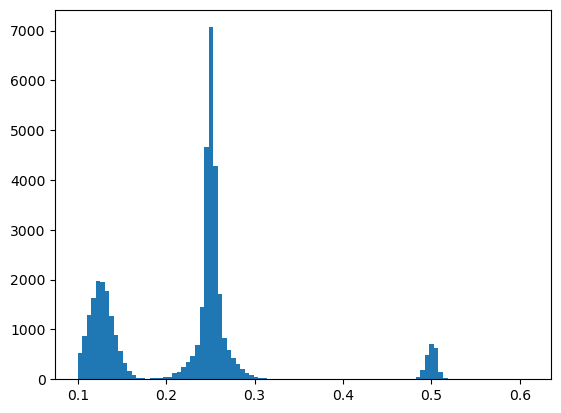

In [39]:
plt.hist(Rel_df["kin"], bins = 100)
plt.show()

In [40]:
#probably want to remove anything above 0.125 (2nd degree relatives) or 0.06535 (3rd degree relatives) for a PRS
#for GWAS remove 0.2 and above (siblings, parents and twins)
Rel_df_rm = Rel_df[Rel_df["kin"] >= 0.2]
len(Rel_df_rm)


26220

In [41]:
PCs_final = PCs_final[~PCs_final['IID'].isin(Rel_df_rm['i.s'])]
len(PCs_final)

390825

## Calculate age

In [42]:
# Calculate age
# Convert birth_datetime to datetime format
current_date = pd.to_datetime("today").date()
wgs_demog["birth_datetime"] = pd.to_datetime(wgs_demog["birth_datetime"]).dt.date
wgs_demog['age'] = wgs_demog['birth_datetime'].apply(lambda x: current_date.year - x.year - ((current_date.month, current_date.day) < (x.month, x.day)))
wgs_demog

,person_id,birth_datetime,sex_at_birth,age
0,1447308,1969-06-15,Sex At Birth: Sex At Birth None Of These,57
1,1459381,1956-06-15,Sex At Birth: Sex At Birth None Of These,70
2,2059577,1998-06-15,Sex At Birth: Sex At Birth None Of These,28
3,2803379,1983-06-15,Sex At Birth: Sex At Birth None Of These,43
4,3496558,1979-06-15,Sex At Birth: Sex At Birth None Of These,47
...,...,...,...,...
414825,1933191,1980-06-15,Female,46
414826,1908005,1948-06-15,Female,78
414827,1628458,1960-06-15,Female,66
414828,1442464,1945-06-15,Female,81


In [43]:
# Merge DataFrames on IID
covariates = PCs_final.merge(wgs_demog, left_on="IID", right_on="person_id", how="left")
covariates.insert(0, "FID", covariates.iloc[:, 0])
covariates = covariates.drop(covariates.columns[21:24], axis=1)
covariates.rename(columns={'sex_code': 'sex'}, inplace=True)
covariates

,FID,IID,ancestry_pred,ancestry_pred_other,PC1,PC2,PC3,PC4,PC5,PC6,...,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,sex,age
0,1000000,1000000,afr,afr,-0.293561,-0.006345,0.002386,0.001446,0.024304,-0.001529,...,-0.000920,0.006886,0.004709,0.004915,0.011461,0.002675,-0.001492,0.000896,1,69
1,1000004,1000004,eur,eur,0.101308,0.138703,0.006683,0.053012,0.003345,0.019714,...,-0.001095,-0.000909,-0.001277,-0.000694,-0.000668,-0.000960,-0.001257,0.000115,1,86
2,1000033,1000033,eur,eur,0.098486,0.124599,0.009398,0.042617,0.003846,0.026659,...,-0.001203,0.000465,0.000469,0.000629,0.000019,-0.000210,-0.000013,0.000411,1,70
3,1000042,1000042,afr,afr,-0.256277,0.004901,-0.002448,0.009514,0.008931,0.010683,...,0.010388,-0.008314,-0.002740,0.003094,0.007370,0.001563,-0.002620,0.006765,1,60
4,1000045,1000045,eas,eas,0.097379,-0.158116,0.044858,0.033242,0.000106,-0.004703,...,-0.000009,0.000727,-0.000209,0.000062,-0.000256,-0.000293,-0.000274,-0.000426,2,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390820,9999678,9999678,eur,eur,0.098743,0.131769,0.010411,0.048562,0.002988,0.021923,...,-0.000634,0.000194,0.000252,-0.001290,0.001715,-0.000752,-0.000415,-0.000020,2,62
390821,9999697,9999697,amr,amr,0.085067,0.028602,-0.107409,0.005666,0.000069,-0.012026,...,0.001513,-0.001535,-0.001271,-0.001320,-0.000950,-0.001408,-0.003327,0.000309,2,40
390822,9999715,9999715,eur,eur,0.099530,0.132836,0.008332,0.050046,0.003166,0.023643,...,-0.001984,-0.001566,0.000294,0.000889,-0.001221,0.001146,-0.000401,0.000165,1,75
390823,9999755,9999755,eur,oth,0.064499,0.116637,0.009492,0.042075,-0.005982,-0.022958,...,0.000953,-0.000316,-0.003218,0.000905,-0.000271,0.000847,0.001971,-0.000443,1,69


## Filter by sex and ancestry

In [44]:
covariates['sex'].value_counts()

sex
2    235268
1    154121
0      1436
Name: count, dtype: int64

In [45]:
covariates_women = covariates[covariates["sex"] == 2] 
len(covariates_women)

235268

In [46]:
covariates_European_women = covariates_women[covariates_women["ancestry_pred"] == "eur"]
len(covariates_European_women)

133658

In [47]:
phenotype_European_women = wgs_cohort[wgs_cohort['person_id'].isin(covariates_European_women['IID'])]
print(len(phenotype_European_women))
phenotype_European_women = phenotype_European_women.merge(covariates_European_women[["IID", "FID"]], left_on="person_id", right_on="IID")
phenotype_European_women = phenotype_European_women.iloc[:, -3:].iloc[:, ::-1]
print(phenotype_European_women.head())

133658
       FID      IID  PID
0  3496558  3496558    0
1  8071156  8071156    0
2  1560790  1560790    0
3  8094101  8094101    0
4  1584564  1584564    0


## save phenotype and covariates file

In [48]:
phenotype_European_women.to_csv(
    f'{bucket_input}/phenotype_European_women.txt',
    index=False, header=False, sep="\t"
)

In [ ]:
covariates_European_women.to_csv(
    f'{bucket_input}/covariates_European_women.txt',
    index=False, header=False, sep="\t"
)

## Push Script to Github

In [50]:
!git config --global user.email "niqimr@gmail.com"
!git config --global user.name "Ningold30"

## Go
'Git' in taskbar -> Initialize a Repository -> 'Git' in taskbar -> Open Git Repository in terminal -> enter the following in the terminal

In [51]:
git remote add origin https://github.com/Ningold30/PID_AoU.git

In [52]:
git branch -M main

In [ ]:
git add /home/jupyter/workspace/workspace-scripts/GWAS_1_DATA_PREPARATION.ipynb
git add /home/jupyter/workspace/workspace-scripts/Var_set.ipynb
git add /home/jupyter/workspace/workspace-scripts/Var_set_2.ipynb